# CIFAR 10 Exercise

We explore 3 different techniques which will later be utilized in anomaly detection algorithms
1. CNNs
2. PCA
3. Autoencoders

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision 
import torchvision.transforms as transforms
import torchsummary as summary
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_built() and torch.backends.mps.is_available():
    device = torch.device("mps")
print(device)

cpu


## 1. Obtaining and prepocessing data

ToTensor - converts values to 0 and 1, and chages shape from 32x32x3 to 3x32x32.
Normalize - first tuple is the mean, 1 value for each channel. second tuple is the sd. new_val = (old_val - 0.5)/0.5. Therefore this normalizes value to be between -1 and 1 which is what CNN prefer.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

Now we can load in the data, and pass in our transform

In [4]:
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download = True, transform=transform)

Here we pass the images in a DataLoader(). This is a tool that helps feed the images into our model in chunks (in this case 4). We shuffle the training data which prevents the model from learning the order, and help it to generalize better.

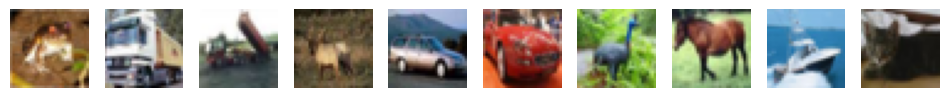

In [5]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=4, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i in range(10):
    image = train_loader.dataset[i][0].permute(1, 2, 0)
    denormalized_image = image /2 + 0.5
    axes[i].imshow(denormalized_image)
    axes[i].axis('off')
plt.show()

## 2. Create our CNN, and construct our forward path.

In [6]:
class ConvNeuraNet(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.conv1 = nn.Conv2d(3, 64, 3)
        self.conv2 = nn.Conv2d(64, 128, 3)

        self.pool = nn.MaxPool2d(2, stride=2)

        self.fc1 = nn.Linear(128 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.log_softmax(self.fc3(x), dim=1)
        return x
    

net = ConvNeuraNet()
net.to(device)

ConvNeuraNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4608, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

## 3. Train our model

In [7]:
loss_function = nn.NLLLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

epochs = 10
for epoch in range(epochs):

    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[{epoch + 1}/{epochs}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')

print('finished training')

[1/10,  2000] loss: 1.798
[1/10,  4000] loss: 3.284
[1/10,  6000] loss: 4.687
[1/10,  8000] loss: 6.057
[1/10, 10000] loss: 7.337
[1/10, 12000] loss: 8.593
[2/10,  2000] loss: 1.160
[2/10,  4000] loss: 2.331
[2/10,  6000] loss: 3.469
[2/10,  8000] loss: 4.594
[2/10, 10000] loss: 5.734
[2/10, 12000] loss: 6.854
[3/10,  2000] loss: 1.016
[3/10,  4000] loss: 2.044
[3/10,  6000] loss: 3.085
[3/10,  8000] loss: 4.106
[3/10, 10000] loss: 5.151
[3/10, 12000] loss: 6.166
[4/10,  2000] loss: 0.924
[4/10,  4000] loss: 1.906
[4/10,  6000] loss: 2.854
[4/10,  8000] loss: 3.812
[4/10, 10000] loss: 4.788
[4/10, 12000] loss: 5.742
[5/10,  2000] loss: 0.870
[5/10,  4000] loss: 1.749
[5/10,  6000] loss: 2.650
[5/10,  8000] loss: 3.530
[5/10, 10000] loss: 4.435
[5/10, 12000] loss: 5.338
[6/10,  2000] loss: 0.813
[6/10,  4000] loss: 1.645
[6/10,  6000] loss: 2.466
[6/10,  8000] loss: 3.307
[6/10, 10000] loss: 4.177
[6/10, 12000] loss: 5.039
[7/10,  2000] loss: 0.748
[7/10,  4000] loss: 1.527
[7/10,  6000